In [2]:
import gzip
import os
import pathlib
import tempfile
from concurrent.futures import ThreadPoolExecutor, as_completed
from io import StringIO, BytesIO

import earthaccess
import geopandas as gpd
import holoviews as hv
import hvplot.pandas
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shapely
import requests
import rioxarray as rxr
import xarray as xr
from tqdm.notebook import tqdm

from download import fetch_hydrocron, download_mrms
from plot import plot_heatmap
from utilities import filter_bits

# Preferences
use_cache = True

# Set up data path
data_dir = pathlib.Path().cwd().parent / 'data'
data_dir.mkdir(exist_ok=True, parents=True)
precip_path = data_dir / 'MRMS_{var_name}.csv'
swot_path = data_dir / 'swot_timeseries_new.csv'

# Satellite tracks for test site on Willamette River
passes = [39, 274, 345]
# Site bounding box
bounds = (-123.4, 44, -123, 45)
bbox = shapely.geometry.box(*bounds)
start_time = '2023-01-01T00:00:00Z'
end_time = '2026-01-01T00:00:00Z'

# Set up data path
data_dir = pathlib.Path().cwd().parent / 'data'
data_dir.mkdir(exist_ok=True, parents=True)
precip_path = data_dir / 'MRMS_{var_name}.csv'
swot_path = data_dir / 'swot_timeseries_new.csv'

In [3]:
swot_ts_df = (
    pd.read_csv(
        swot_path, 
        na_values=['no_data'],
        index_col=['node_id', 'time_str'],
        parse_dates=True)
    .rename_axis(index={"time_str": "time"})
)
# Remove NA rows
swot_ts_df = swot_ts_df[swot_ts_df.index.get_level_values("time").notna()]

# Filter data
swot_filter_df = swot_ts_df.copy()
# Not ice
swot_filter_df = swot_filter_df[swot_filter_df.ice_clim_f==0]
# Not bad xover
swot_filter_df = swot_filter_df[swot_filter_df.xovr_cal_q<2]
# Not far or near swath
swot_filter_df = swot_filter_df[swot_filter_df.node_q_b.apply(filter_bits)]

swot_filter_df

/var/folders/h8/7yhvl39x7dn5889b60w34ty40000gs/T/ipykernel_9522/2795151691.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.read_csv(


wse       width  area_total  \
node_id        time                                                           
78220000150161 2023-04-02 08:16:14+00:00   34.16688  195.199060     36166.8   
               2023-04-03 08:06:52+00:00   33.43470  182.996079     33905.8   
               2023-04-04 07:57:29+00:00   33.74396  192.101922     35592.9   
               2023-04-05 07:48:07+00:00   33.55678  193.177358     35792.2   
               2023-04-07 07:29:23+00:00   33.43993  191.753879     35528.5   
...                                             ...         ...         ...   
78220000310421 2025-03-18 16:34:31+00:00  136.84534  283.224489     54692.6   
               2025-03-27 01:38:41+00:00  137.78587  359.456110     69413.5   
               2025-04-08 13:19:35+00:00  137.00987  285.692607     55169.2   
               2025-04-16 22:23:46+00:00  136.71169  301.025842     58130.2   
               2025-04-29 10:04:40+00:00  136.78508  273.511283     52816.9   

                                          node_q_b  ice_clim_f  xovr_cal_q  \
node_id        time                                                          
78220000150161 2023-04-02 08:16:14+00:00         6           0           0   
               2023-04-03 08:06:52+00:00        14           0           0   
               2023-04-04 07:57:29+00:00         6           0           0   
               2023-04-05 07:48:07+00:00         6           0           0   
               2023-04-07 07:29:23+00:00        14           0           0   
...                                            ...         ...         ...   
78220000310421 2025-03-18 16:34:31+00:00         4           0           1   
               2025-03-27 01:38:41+00:00         6           0           1   
               2025-04-08 13:19:35+00:00         6           0           1   
               2025-04-16 22:23:46+00:00    524298           0           1   
               2025-04-29 10:04:40+00:00         7           0           1   

                                          p_dam_id  dark_frac  n_good_pix  \
node_id        time                                                         
78220000150161 2023-04-02 08:16:14+00:00         0   0.056718          26   
               2023-04-03 08:06:52+00:00         0   0.043202          39   
               2023-04-04 07:57:29+00:00         0   0.024670          29   
               2023-04-05 07:48:07+00:00         0   0.008181          49   
               2023-04-07 07:29:23+00:00         0   0.074218          35   
...                                            ...        ...         ...   
78220000310421 2025-03-18 16:34:31+00:00         0   0.029487          58   
               2025-03-27 01:38:41+00:00         0   0.000000          64   
               2025-04-08 13:19:35+00:00         0   0.000000          63   
               2025-04-16 22:23:46+00:00         0   0.014839          45   
               2025-04-29 10:04:40+00:00         0   0.000000          53   

                                                lat  ...  rdr_sig0_units  \
node_id        time                                  ...                   
78220000150161 2023-04-02 08:16:14+00:00  44.991207  ...               1   
               2023-04-03 08:06:52+00:00  44.991169  ...               1   
               2023-04-04 07:57:29+00:00  44.991097  ...               1   
               2023-04-05 07:48:07+00:00  44.990991  ...               1   
               2023-04-07 07:29:23+00:00  44.991151  ...               1   
...                                             ...  ...             ...   
78220000310421 2025-03-18 16:34:31+00:00  44.026216  ...               1   
               2025-03-27 01:38:41+00:00  44.026300  ...               1   
               2025-04-08 13:19:35+00:00  44.026338  ...               1   
               2025-04-16 22:23:46+00:00  44.025971  ...               1   
               2025-04-29 10:04:40+00:00  44.026354  ...               1   

              

In [4]:
precip_flag_path = "/Users/masa6503/Library/CloudStorage/OneDrive-UCB-O365/Documents/SWOT/swot-precip-validation/data/MRMS_PrecipFlag_00.00.csv"
precip_flag_df = pd.read_csv(
    precip_flag_path, 
    # index_col=['node_id', 'time'],
    parse_dates=True
)

precip_flag_df.rename(columns={'PrecipFlag_00.00': 'precip_flag'}, inplace=True)
precip_flag_df['time'] = pd.to_datetime(precip_flag_df['time'])
precip_flag_df.set_index(['node_id', 'time'], inplace=True)
precip_flag_df['precip_flag_binary'] = precip_flag_df.precip_flag.isin([1, 6, 7, 10, 91, 96])


precip_rate_path = "/Users/masa6503/Library/CloudStorage/OneDrive-UCB-O365/Documents/SWOT/swot-precip-validation/data/MRMS_PrecipRate_00.00.csv"
precip_rate_df = pd.read_csv(
    precip_rate_path, 
    # index_col=['node_id', 'time'],
    parse_dates=True
)

precip_rate_df.rename(columns={'PrecipRate_00.00': 'precip_rate'}, inplace=True)
precip_rate_df['time'] = pd.to_datetime(precip_rate_df['time'])
precip_rate_df.set_index(['node_id', 'time'], inplace=True)


In [5]:
precip_quality_path = "/Users/masa6503/Library/CloudStorage/OneDrive-UCB-O365/Documents/SWOT/swot-precip-validation/data/MRMS_RadarAccumulationQualityIndex_01H_00.00.csv"
precip_quality_df = pd.read_csv(
    precip_quality_path, 
    # index_col=['node_id', 'time'],
    parse_dates=True
)

precip_quality_df.rename(columns={'RadarAccumulationQualityIndex_01H_00.00': 'radar_quality'}, inplace=True)
precip_quality_df['time'] = pd.to_datetime(precip_quality_df['time'])
precip_quality_df.set_index(['node_id', 'time'], inplace=True)


In [6]:
flag_mapping = {
    -3: 'No Coverage',
    0: 'No Precip',
    1: 'Warm Stratiform',
    3: 'Snow',
    6: 'Convective Rain',
    7: 'Rain Mixed Hail',
    10: 'Cold Stratiform ',
    91: 'Tropical/stratiform',
    96: 'Tropical/convective'
}

swot_precip_rate_flag_df = (
    swot_ts_df
    .merge(
        precip_rate_df,
        on=['node_id', 'time']
        )
    .merge(
        precip_flag_df,
        on=['node_id', 'time']
    )
    .merge(
        precip_quality_df,
        on=['node_id', 'time']
    )
    .query(
        "wse>=0 & radar_quality>0.3"
    )
    .assign(precip_type_labeled = lambda df: df['precip_flag'].map(flag_mapping)).fillna("Unknown")
)

<Axes: xlabel='precip_type_labeled', ylabel='dark_frac'>

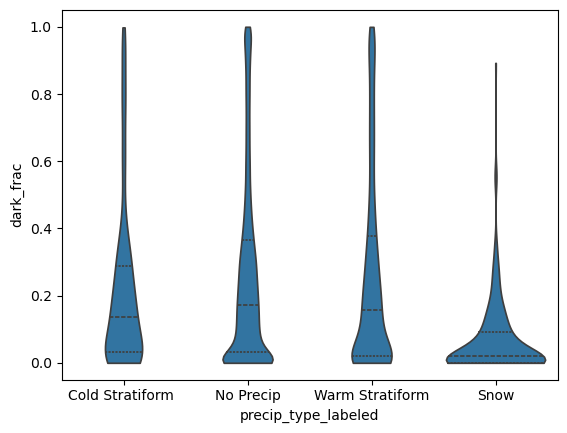

In [88]:
sns.violinplot(
    data=swot_precip_rate_flag_df,
    x='precip_type_labeled', y='dark_frac', log_scale=False,
    inner='quartile',
    cut=0
)

<Axes: xlabel='precip_type_labeled', ylabel='rdr_sig0'>

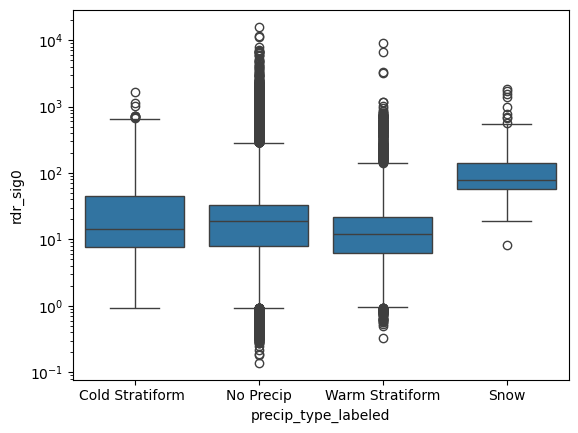

In [102]:
sns.boxplot(
    data=swot_precip_rate_flag_df,
    x='precip_type_labeled', y='rdr_sig0', log_scale=True
)

In [7]:
n_precip_cats = 9
swot_precip_rate_flag_df['precip_bin_mm_hr'] = pd.cut(swot_precip_rate_flag_df.precip_rate, [-1,0,1,2,3,4,5,6,7,8,9,10,11,12,13], labels = ['0','0-1','1-2','2-3','3-4','4-5','5-6','6-7','7-8','8-9','9-10', '10-11','11-12','12-13'])

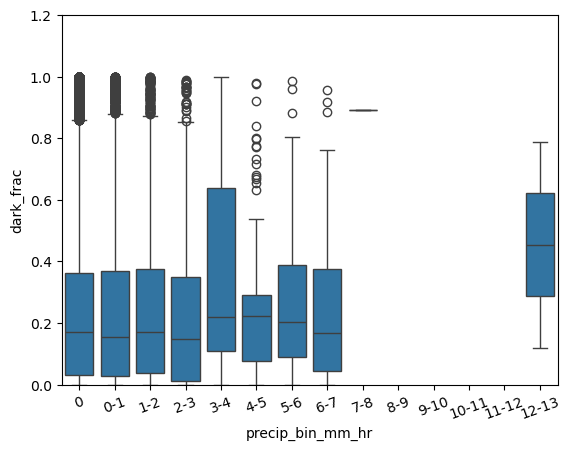

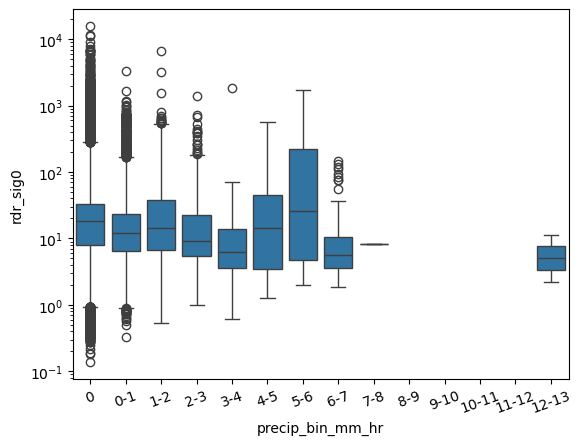

In [116]:
sns.boxplot(
    data=swot_precip_rate_flag_df,
    x='precip_bin_mm_hr', y='dark_frac', log_scale=False
)
plt.ylim(0,1.2)
# Tilt the labels 45 degrees
plt.xticks(rotation=20)
plt.show()

sns.boxplot(
    data=swot_precip_rate_flag_df,
    x='precip_bin_mm_hr', y='rdr_sig0', log_scale=True
)
# plt.ylim(0,1.2)
# Tilt the labels 45 degrees
plt.xticks(rotation=20)
plt.show()

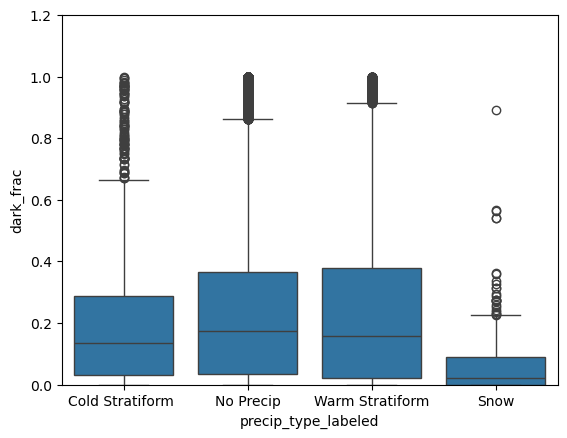

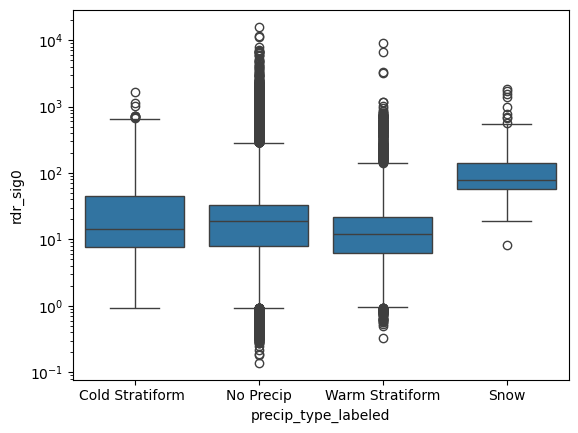

In [118]:
sns.boxplot(
    data=swot_precip_rate_flag_df,
    x='precip_type_labeled', y='dark_frac', log_scale=False
)
plt.ylim(0,1.2)
# Tilt the labels 45 degrees
# plt.xticks(rotation=20)
plt.show()

sns.boxplot(
    data=swot_precip_rate_flag_df,
    x='precip_type_labeled', y='rdr_sig0', log_scale=True
)
# plt.ylim(0,1.2)
# Tilt the labels 45 degrees
# plt.xticks(rotation=20)
plt.show()

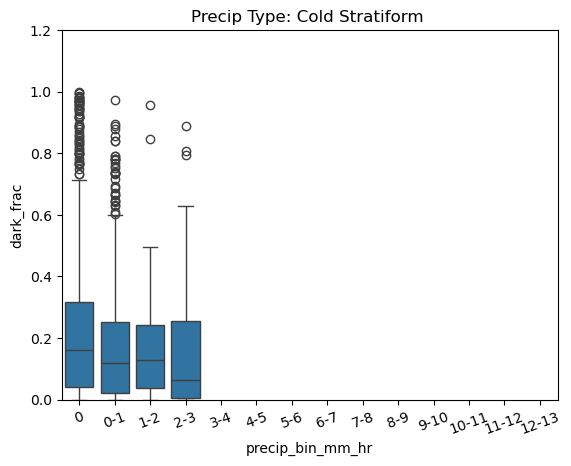

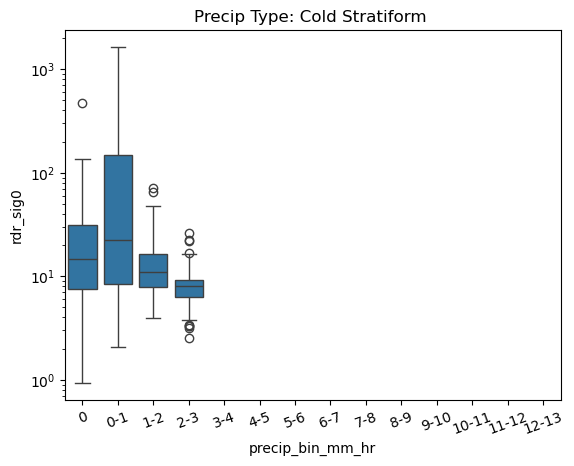

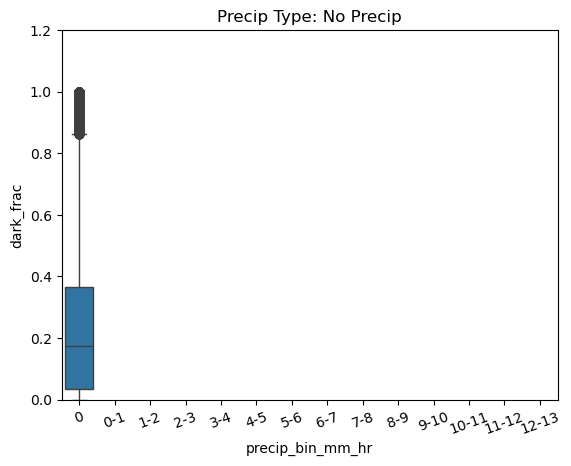

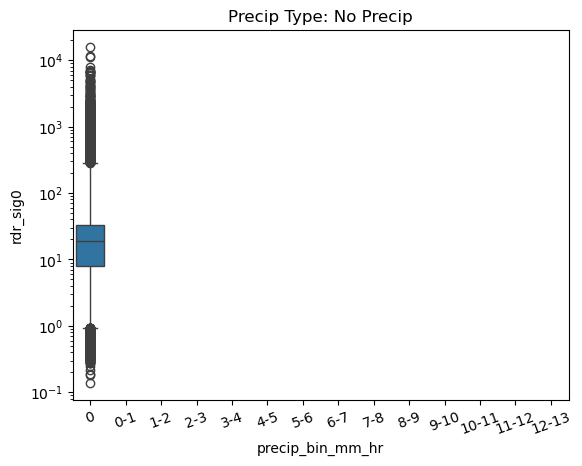

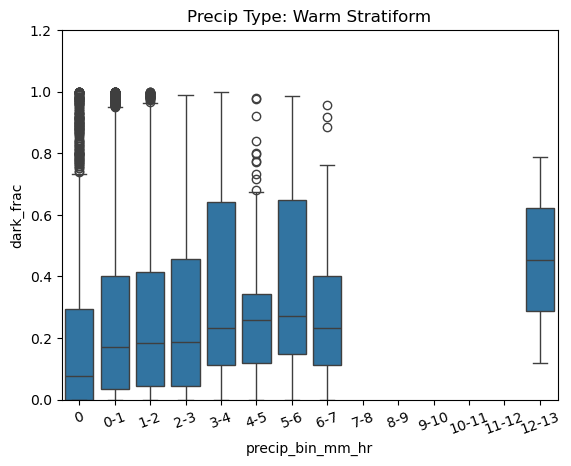

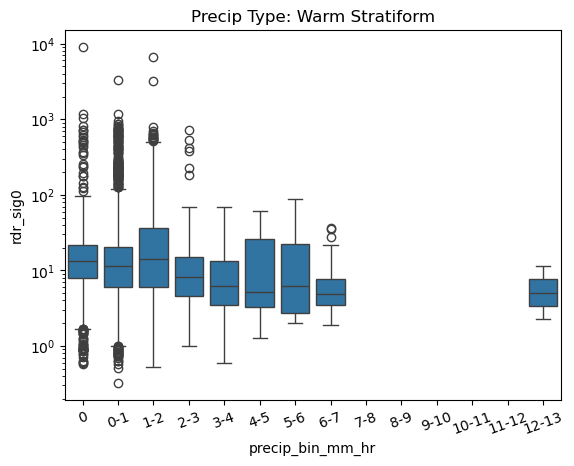

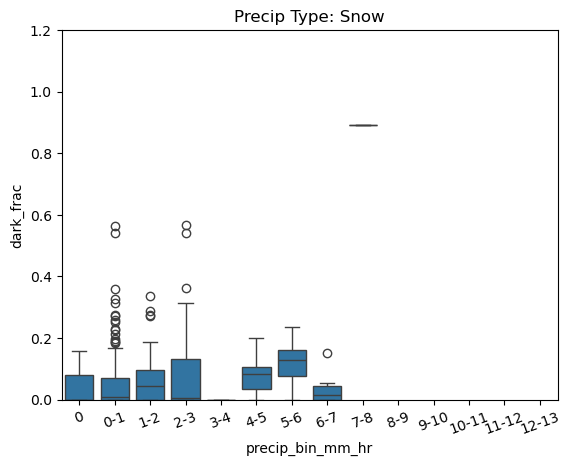

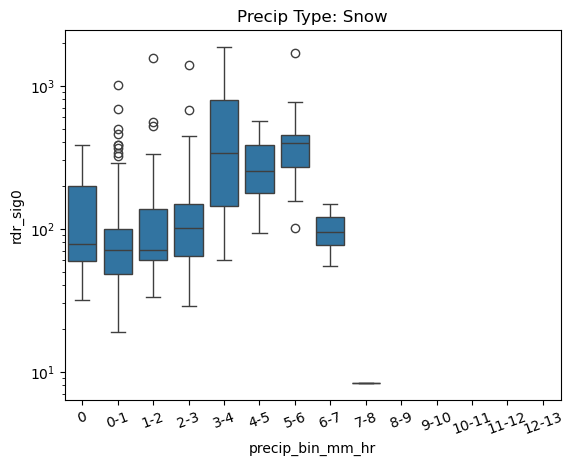

In [120]:
for precip_type in swot_precip_rate_flag_df['precip_type_labeled'].unique():
    subset = swot_precip_rate_flag_df[swot_precip_rate_flag_df['precip_type_labeled'] == precip_type]
    sns.boxplot(
        data=subset,
        x='precip_bin_mm_hr', y='dark_frac', log_scale=False
    )
    plt.ylim(0,1.2)
    # Tilt the labels 45 degrees
    plt.xticks(rotation=20)
    plt.title(f'Precip Type: {precip_type}')
    plt.show()

    sns.boxplot(
        data=subset,
        x='precip_bin_mm_hr', y='rdr_sig0', log_scale=True
    )
    # plt.ylim(0,1.2)
    # Tilt the labels 45 degrees
    plt.xticks(rotation=20)
    plt.title(f'Precip Type: {precip_type}')
    plt.show()
    

In [8]:
import dataretrieval.waterdata as waterdata

In [9]:
pcodes,metadata = waterdata.get_reference_table("parameter-codes")
# display(pcodes.head())

streamflow_pcodes = pcodes[pcodes['parameter_name'].str.contains('gauge|height', case=False, na=False)]
display(streamflow_pcodes[['parameter_code', 'parameter_name', 'parameter_description']])

,parameter_code,parameter_name,parameter_description
47,00065,Gage height,"Gage height, feet"
1700,30207,GageHeightAboveDatum,"Gage height, above datum, meters"
3204,45591,"Gate opening, height","Gate opening, height, meters"
3205,45592,"Gate opening, height","Gate opening, height, feet"
13747,70233,Significant wave height,"Significant wave height, feet"
13748,70234,Maximum wave height,"Wave height, maximum, feet"
14001,72172,"Wave height, Fourier","Wave height, Fourier transformation, feet"
14111,72284,Mean wave height,"Wave height, mean, meters"
14115,72288,Maximum wave height,"Wave height, maximum, meters"
18709,99065,Gage height,"Gage height, above datum, meters"


In [111]:
loc_id = 'USGS-14158050'
parameter_codes = ['00065', '30207', '99065']
statistic_id = '00011'
timeseries = "2023-01-01T00:00:00Z/2026-01-01T12:31:12Z"
elevation_data = waterdata.get_continuous(
    monitoring_location_id=loc_id,
    parameter_code=parameter_codes,
    time=timeseries,
    statistic_id=statistic_id
    )
location_info = waterdata.get_monitoring_locations(
    monitoring_location_id=loc_id,
    properties=['altitude','altitude_accuracy', 'altitude_method_name',
                'vertical_datum', 'vertical_datum_name', 'horizontal_positional_accuracy',
                'geometry']
)


In [113]:
target_lon = location_info[0]['geometry'].x[0]
target_lat = location_info[0]['geometry'].y[0]

In [114]:
# Get mean lat and lon by node
lat_lon = swot_filter_df[['lat','lon']].groupby('node_id').mean()

In [115]:
dist = np.sqrt(
    (lat_lon['lat'] - target_lat)**2 +
    (lat_lon['lon'] - target_lon)**2
)

closest_node = dist.idxmin()
closest_row = lat_lon.loc[closest_node]

print("Closest node_id:", closest_node)
print(closest_row)


Closest node_id: 78220000300551
lat     44.053004
lon   -123.081643
Name: 78220000300551, dtype: float64


In [116]:
dist.sort_values()

node_id
78220000300551    0.001241
78220000300541    0.001649
78220000300561    0.003371
78220000300531    0.004309
78220000300571    0.005689
                    ...   
78220000150151    0.940600
78220000150141    0.942139
78220000150131    0.943695
78220000150121    0.945330
78220000150111    0.947100
Length: 870, dtype: float64

In [117]:
node_id = closest_node
closest_node_data = swot_filter_df.query(f'node_id=={node_id}')[['wse']]
# Round only the time level
closest_node_data['time_15min'] = (
    pd.to_datetime(
        closest_node_data.index.get_level_values('time')
    ).round('15min')
)

In [118]:
closest_node_data = closest_node_data.merge(elevation_data[0], left_on="time_15min", right_on="time", how="left")

In [119]:
closest_node_data[['time_15min','wse','value']]

,time_15min,wse,value
0,2023-04-21 05:15:00+00:00,136.52935,11.96
1,2023-05-03 03:30:00+00:00,140.00190,11.86
2,2023-05-05 03:00:00+00:00,140.17901,11.63
3,2023-05-08 02:45:00+00:00,140.20794,11.28
4,2023-05-10 02:15:00+00:00,139.72784,11.11
5,2023-05-11 02:15:00+00:00,122.04033,11.07
6,2023-05-12 02:00:00+00:00,139.98796,10.87
7,2023-05-16 01:30:00+00:00,139.76490,11.06
8,2023-05-17 01:15:00+00:00,139.99992,11.34
9,2023-05-23 00:15:00+00:00,139.63425,10.85


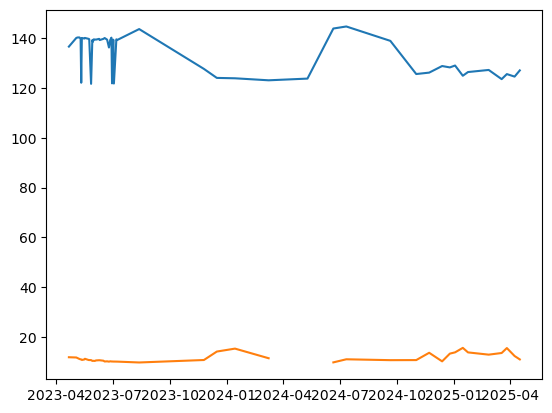

In [120]:
plt.plot(closest_node_data['time_15min'], closest_node_data['wse'])
plt.plot(closest_node_data['time_15min'], closest_node_data['value'])

In [86]:
elevation_data[0].time

0        2023-01-01 00:00:00+00:00
1        2023-01-01 00:15:00+00:00
2        2023-01-01 00:30:00+00:00
3        2023-01-01 00:45:00+00:00
4        2023-01-01 01:00:00+00:00
                    ...           
154291   2026-01-01 11:30:00+00:00
154292   2026-01-01 11:45:00+00:00
154293   2026-01-01 12:00:00+00:00
154294   2026-01-01 12:15:00+00:00
154295   2026-01-01 12:30:00+00:00
Name: time, Length: 154296, dtype: datetime64[ns, UTC]

In [44]:
test = swot_filter_df[['lat','lon']].query("node_id == 78220000150111")

In [46]:
test['lat'].describe()

count    114.000000
mean      44.999501
std        0.000255
min       44.998768
25%       44.999437
50%       44.999505
75%       44.999543
max       45.000411
Name: lat, dtype: float64

In [45]:
test

lat         lon
node_id        time                                            
78220000150111 2023-04-02 08:16:14+00:00  44.999330 -123.069367
               2023-04-03 08:06:52+00:00  44.999451 -123.069194
               2023-04-04 07:57:29+00:00  44.999417 -123.069213
               2023-04-05 07:48:07+00:00  44.999426 -123.069224
               2023-04-07 07:29:23+00:00  44.999381 -123.069259
...                                             ...         ...
               2025-03-18 16:34:42+00:00  44.999747 -123.068226
               2025-03-29 14:57:38+00:00  44.999511 -123.069069
               2025-04-08 13:19:46+00:00  44.999657 -123.069184
               2025-04-19 11:42:44+00:00  44.999534 -123.069029
               2025-04-29 10:04:51+00:00  44.998775 -123.069042

[114 rows x 2 columns]